# **MÓDULO 39 - Exercicio - Aplicando XGboost**

Nessa atividade vocês usarão uma base já connhecida, a base de propensão a compra de carros.
Já utilizamos essa base antes, nessa atividade, você deve carregar a base, realizar os tratamentos necessários, rodar o XGBoost, encontrar as principais variaveis.
Vamos lá!

In [1]:
import xgboost as xgb
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier

In [2]:
pip install Xgboost

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 26.2.1
[notice] To update, run: C:\Users\Regina\AppData\Local\Programs\Python\Python313\python.exe -m pip install --upgrade pip


# 1. Carrega a base de dados, verifique os tipos de dados, dados faltantes e drop a coluna ID.


In [3]:
df = pd.read_csv('CARRO_CLIENTES.csv')

In [4]:
df

,User ID,Gender,Age,AnnualSalary,Purchased
0,385,Male,35,20000,0
1,681,Male,40,43500,0
2,353,Male,49,74000,0
3,895,Male,40,107500,1
4,661,Male,25,79000,0
...,...,...,...,...,...
995,863,Male,38,59000,0
996,800,Female,47,23500,0
997,407,Female,28,138500,1
998,299,Female,48,134000,1


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   User ID       1000 non-null   int64
 1   Gender        1000 non-null   str  
 2   Age           1000 non-null   int64
 3   AnnualSalary  1000 non-null   int64
 4   Purchased     1000 non-null   int64
dtypes: int64(4), str(1)
memory usage: 39.2 KB


In [6]:
df.isnull().sum()

User ID         0
Gender          0
Age             0
AnnualSalary    0
Purchased       0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df = df.drop(columns=['User ID'])

In [9]:
df

,Gender,Age,AnnualSalary,Purchased
0,Male,35,20000,0
1,Male,40,43500,0
2,Male,49,74000,0
3,Male,40,107500,1
4,Male,25,79000,0
...,...,...,...,...
995,Male,38,59000,0
996,Female,47,23500,0
997,Female,28,138500,1
998,Female,48,134000,1


# 2. Aplique o Label Encoder para a coluna Gender e exclua a coluna categórica.

In [10]:
le = LabelEncoder()
df['Gender_encoded'] = le.fit_transform(df['Gender'])
df.drop(columns=['Gender'], inplace=True)

In [11]:
df

,Age,AnnualSalary,Purchased,Gender_encoded
0,35,20000,0,1
1,40,43500,0,1
2,49,74000,0,1
3,40,107500,1,1
4,25,79000,0,1
...,...,...,...,...
995,38,59000,0,1
996,47,23500,0,0
997,28,138500,1,0
998,48,134000,1,0


# 3. Faça a matriz de correlação e analise as váriaveis que parecem ter maior correlação com a váriavel target.

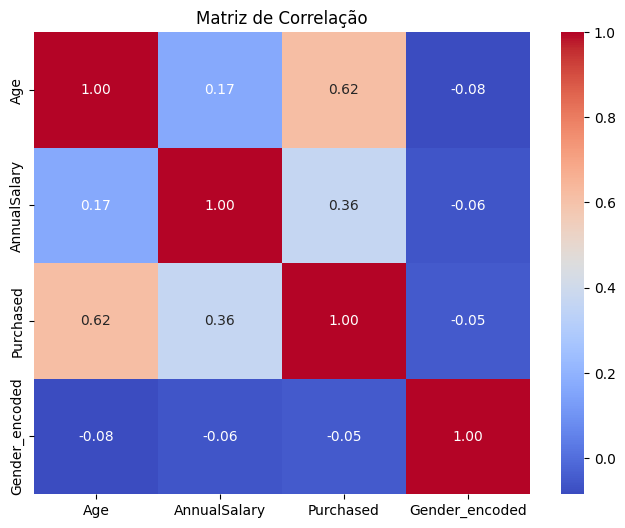

In [12]:
corr = df.corr(numeric_only=True)
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Matriz de Correlação')
plt.show()

As duas variáveis que tem correlaçao mais forte e positiva com a variável target são idade(0.62) e salário anual(0.36). Com o aumento da idade e do salário existe uma maior tendência do purshased = 1.

# 4. Faça a separação da base em X e Y e em seguida nas bases de treino e teste.

In [13]:
X = df.drop(columns=['Purchased'])
y = df['Purchased']
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.2, random_state=42)

In [14]:
print(X_train.shape)
print(y_train.shape)

(800, 3)
(800,)


# 5. Treino o modelo Xgboost com sua base de treino.
Pesquise alguns hyperparametros na bibllioteca para utilizar, utilize ao menos 2.

In [15]:
modelo = XGBClassifier(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.1,
    random_state=42
)



In [16]:
modelo.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.objective.Objective, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets im

# 6. Realize as previsões para a base de teste e traga as probabilidades das previsões.

In [17]:
y_pred = modelo.predict(X_test)
y_proba = modelo.predict_proba(X_test)
print(y_pred, y_proba)

[0 1 0 0 1 1 1 0 0 0 0 0 0 0 1 1 0 1 1 0 0 1 1 0 1 0 1 1 0 0 0 1 1 0 1 0 0
 0 0 1 0 0 1 0 1 0 0 1 0 0 1 1 0 1 0 1 1 0 0 1 0 0 0 1 0 0 0 0 1 0 1 0 0 0
 1 0 1 0 0 0 0 0 1 1 0 0 1 0 0 0 0 1 0 0 1 1 1 0 0 0 1 1 1 1 1 1 0 1 1 1 0
 0 0 1 1 0 1 1 0 0 0 1 1 0 1 0 0 1 0 1 0 0 1 0 0 1 0 0 0 0 1 0 0 0 1 0 0 0
 1 1 1 0 0 0 0 0 0 0 1 0 0 0 0 1 1 0 1 0 0 0 0 0 1 0 0 0 1 0 1 1 1 1 0 0 0
 1 1 1 1 1 0 0 0 1 0 0 0 1 0 1] [[8.06041718e-01 1.93958268e-01]
 [2.47410536e-02 9.75258946e-01]
 [9.99187589e-01 8.12382495e-04]
 [7.17386603e-01 2.82613426e-01]
 [2.82734871e-01 7.17265129e-01]
 [7.80916810e-02 9.21908319e-01]
 [6.83760643e-03 9.93162394e-01]
 [9.95907962e-01 4.09201253e-03]
 [9.75347400e-01 2.46525966e-02]
 [9.80053008e-01 1.99469849e-02]
 [9.17530298e-01 8.24696720e-02]
 [9.98704970e-01 1.29502290e-03]
 [8.91764224e-01 1.08235776e-01]
 [9.95625794e-01 4.37422609e-03]
 [4.51603532e-02 9.54839647e-01]
 [2.18210340e-01 7.81789660e-01]
 [5.24948239e-01 4.75051731e-01]
 [9.79163051e-02 9.02083695e-01]

# 7. Faça a transformação das probabilidades nas previsões binárias e avalie o desempenho do modelo.

In [18]:
y_pred_original = le.inverse_transform(y_pred)
y_test_original = le.inverse_transform(y_test)

conf_matrix = confusion_matrix(y_test, y_pred)
print(conf_matrix)

[[106   6]
 [ 13  75]]


In [33]:
accuracy = accuracy_score(y_test_original, y_pred_original)
print(accuracy)

0.905


In [19]:
report = classification_report(y_test, y_pred)
print(report)

              precision    recall  f1-score   support

           0       0.89      0.95      0.92       112
           1       0.93      0.85      0.89        88

    accuracy                           0.91       200
   macro avg       0.91      0.90      0.90       200
weighted avg       0.91      0.91      0.90       200



                Não compra     Compra
Não compra:       [106          6]

Compra:           [ 13         75]

#106: eram não compra e ele acertou, 6 ele errou apontando como compra mas não era.
#13:  eram compra e ele disse não compra, 75 eram compra e ele acertou.

o modelo teve 6 falsos positivos e 13 falsos negativos, além de 106 verdadeiros negativos e 75 verdadeiros positivos.



# 8. Traga a lista com a feature importance.
As features mais importantes são as mesmas que indicaram maior correlação na matriz de correlação?

In [36]:
importances = modelo.get_booster().get_score(importance_type='gain')

In [38]:
importances_df = pd.DataFrame(list(importances.items()), columns = ['Feature', 'Importance'])
importances_df['Importance'] = importances_df['Importance'].astype(float)
importances_df = importances_df.sort_values(by = 'Importance', ascending = False)
print(importances_df)

          Feature  Importance
0             Age   11.918821
1    AnnualSalary    6.240239
2  Gender_encoded    1.159402


Sim, são as mesmas. As duas variáveis que apresentaram correlação mais forte e positiva com a variável target foram idade(0.62) e salário anual(0.36). Assim como aqui a importância de idade e salário são as maiores.

Correção da atividade:
A tarefa está bem desenvolvida e foi feito de forma organizada e atendeu aos objetivos da atividade, realizando corretamente o carregamento da base de propensão à compra de carros, a verificação dos tipos de dados, a análise de valores ausentes e a remoção da coluna identificadora, que não agregava valor preditivo ao modelo.

A aplicação do Label Encoder na variável categórica foi executada adequadamente, permitindo a utilização do algoritmo XGBoost. A análise exploratória por meio da matriz de correlação foi bem interpretada, identificando idade e salário anual como as variáveis mais relacionadas à variável-alvo, conclusão posteriormente confirmada pela análise de importância das variáveis.

O modelo XGBoost foi treinado utilizando hiperparâmetros relevantes, alcançando uma acurácia muito boa, resultado bastante satisfatório para o problema proposto. Além disso, a avaliação do desempenho foi complementada pela matriz de confusão, demonstrando boa compreensão dos conceitos de verdadeiros positivos, verdadeiros negativos, falsos positivos e falsos negativos.

Para pontos de melhoria, seria interessante complementar a análise com métricas adicionais, como precisão, recall e F1-score, além de explorar técnicas de ajuste de hiperparâmetros para verificar possíveis ganhos de desempenho.

No geral, o trabalho mostrou domínio das etapas de preparação dos dados, modelagem e interpretação dos resultados com XGBoost.

Parabéns!

Qualquer dúvida estamos à disposição.